# ÍNDICES ESPECTRALES Y SERIES TEMPORALES DE MÚLTIPLES SENSORES  

**Curso:** Geoprocesamiento  
**Programa:** Maestría en Geomática  
**Periodo:** 2026-2  
**Fecha:** 11/09/2026

**Estudiante:** Gizela Andrea Guzmán Lugo

>  1. Elige un índice distinto del NDVI (por ejemplo, **EVI**, **SAVI** o **NDWI**) para evaluar el dosel, el suelo o la humedad.
> 2. Genera composiciones medias anuales tanto para **Sentinel-2** como para **Landsat 8** en tu zona, aplicando el enmascaramiento de nubes específico del sensor (SCL / QA_PIXEL) y los factores de escala de la reflectancia superficial de Landsat 8.
> 3. **Crea Stacks multitemporales:** Combine las 10 capas de índices anuales (de 2016 a 2025) en una única pila `ee.Image` de 10 bandas para Sentinel-2 y una stack correspondiente de 10 bandas para Landsat 8 (renombrando las bandas secuencialmente como `Index_2016`, `Index_2017`, ..., `Index_2025`).
>4. **Exportación a GeoTIFF:** Exporta ambos stacks de imágenes de 10 bandas a Google Drive como rásteres GeoTIFF proyectados con el SCR local oficial de Colombia (**EPSG:9377**).


## 0. Librerias

In [74]:
import geopandas as gpd  # permite trabajar con información geográfica vectorial
import rasterio # permite leer, escribir y analizar datos ráster
import rasterio.mask # módulo para recortar un ráster utilizando una geometría vectorial
import rasterio.warp # módulo para transformar espacialmente un ráster
from rasterio.enums import Resampling # método utilizado para calcular los nuevos valores al resamplear
import ee # permite acceder desde Python a Google Earth Engine
import numpy as np # permite trabajar con matrices
import matplotlib.pyplot as plt # permite crear gráficos y visualizar información
from pathlib import Path # permite manejar rutas, carpetas y archivos

## 1. Autenticación Google Earth Engine


* Se establece una conexión autenticada con la API de Google Earth Engine.

* `ee.Authenticate()` verifica las credenciales de acceso del usuario.

* `ee.Initialize()` inicia la sesión utilizando el proyecto de Google asociado.

In [75]:
ee.Authenticate()

True

In [76]:
# Inicializar Google Earth Engine API
try:
    ee.Initialize(project="soy-analog-460212-b6")
    print("Google Earth Engine initialised successfully.")
except Exception as e:
    print(f"Error initialising GEE: {e}")

Google Earth Engine initialised successfully.


## 2. Preprocesamiento de datos vectoriales


### 2.1 Cargue de datos

* Se define una ruta mediante `pathlib.Path` para acceder a los archivos espaciales del proyecto.
* Se carga la capa de municipios de Colombia y se consulta su sistema de referencia de coordenadas original.
* La información se reproyecta al sistema MAGNA-SIRGAS / Origen Nacional (EPSG:9377)
* Se visualizan los primeros registros y atributos del GeoDataFrame para verificar la correcta lectura y transformación de los datos.

In [77]:
# Cargar la capa de municipios
root_folder=Path(r"C:\Users\USER\OneDrive\Documentos\GEOPROCESAMIENTO\Clase1_01092026")

gdf = gpd.read_file(root_folder /"municipios_colombia.gpkg")

# Mostrar el sistema de referencia espacial inicial
print(f"Initial CRS: {gdf.crs}")

# Reproyectar a EPSG:9377
gdf_unico = gdf.to_crs(epsg=9377)

# Consultar la tabla de atributos 
gdf_unico.head()


Initial CRS: EPSG:3116


,DPTO_CCDGO,MPIO_CCDGO,MPIO_CNMBR,MPIO_CDPMP,VERSION,AREA,LATITUD,LONGITUD,STCTNENCUE,STP3_1_SI,...,STP51_PRIM,STP51_SECU,STP51_SUPE,STP51_POST,STP51_13_E,STP51_99_E,Shape_Leng,Shape_Area,Codigo_Mun,geometry
0,18,001,FLORENCIA,18001,2018,2.547638e+09,1.749139,-75.558239,71877.0,32.0,...,48848.0,59610.0,21898.0,4592.0,5892.0,3799.0,2.942508,0.206928,18001,"MULTIPOLYGON (((4730856.146 1800689.038, 47308..."
1,18,029,ALBANIA,18029,2018,4.141221e+08,1.227865,-75.882327,2825.0,24.0,...,1940.0,1712.0,231.0,41.0,215.0,46.0,1.112829,0.033618,18029,"MULTIPOLYGON (((4677933.827 1709133.846, 46779..."
2,18,094,BELÉN DE LOS ANDAQUÍES,18094,2018,1.191619e+09,1.500923,-75.875645,4243.0,54.0,...,3541.0,3340.0,490.0,119.0,720.0,123.0,2.234657,0.096745,18094,"MULTIPOLYGON (((4690015.614 1751610.86, 469000..."
3,18,247,EL DONCELLO,18247,2018,1.106076e+09,1.791386,-75.193944,8809.0,0.0,...,7571.0,6287.0,1029.0,228.0,1095.0,171.0,3.154370,0.089867,18247,"MULTIPOLYGON (((4737450.122 1814755.048, 47374..."
4,18,256,EL PAUJÍL,18256,2018,1.234734e+09,1.617746,-75.234043,5795.0,0.0,...,6072.0,4066.0,639.0,108.0,916.0,99.0,3.529316,0.100309,18256,"MULTIPOLYGON (((4736905.653 1802381.382, 47376..."


* Se selecciona un municipio mediante un filtro aplicado al atributo MPIO_CNMBR
* Se verifica que la consulta haya encontrado un registro. 
* Se genera un buffer de 500 metros alrededor de su límite municipal y se asigna el resultado como la geometría activa de un nuevo GeoDataFrame. 
* Se comprueba el tipo de geometría obtenido y se representa gráficamente el área resultante.

In [123]:
# Filtro de Municipio 
gdf_muni = gdf_unico[gdf_unico["MPIO_CNMBR"] == "CIRCASIA"].copy()
print("Municipios seleccionados:", len(gdf_muni))

Municipios seleccionados: 1


### 2.2 Buffer Municipio

In [124]:
# Se aplica un buffer de 500 m al municipio seleccionado
buffered_shape = gdf_muni.geometry.buffer(500)

# Se crea un nuevo geodataframe con el resultado del buffer
gdf_buffered = gdf_muni.copy()
gdf_buffered.set_geometry(buffered_shape, inplace=True)
print(f"Buffered Geometry Type: {gdf_buffered.geometry.type.iloc[0]}")

Buffered Geometry Type: Polygon


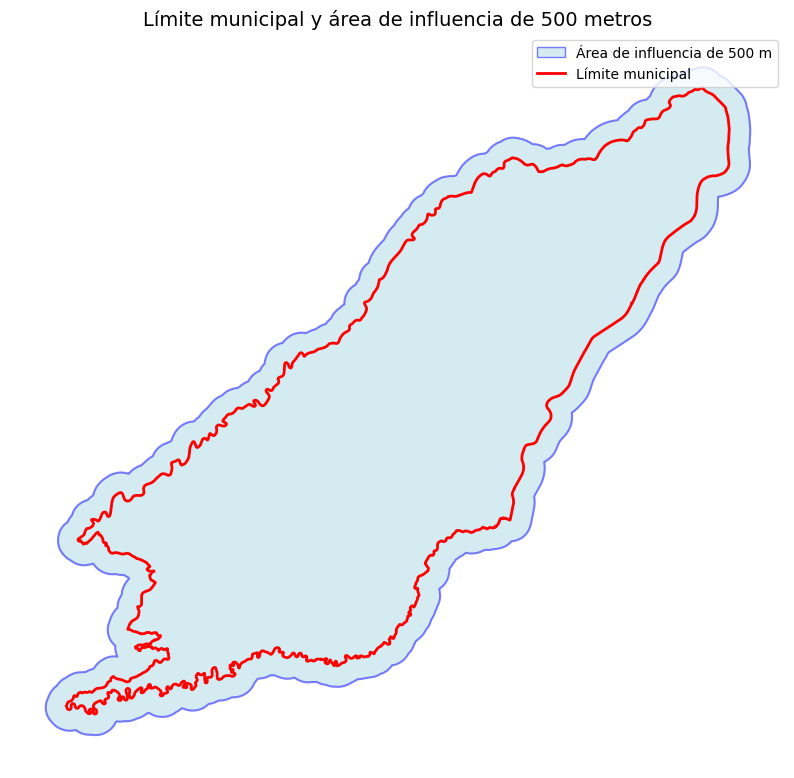

In [125]:
# Crear la figura
import matplotlib.pyplot as plt
from matplotlib.patches import Patch # permite crear un símbolo de tipo polígono para la leyenda
from matplotlib.lines import Line2D # permite crear un símbolo lineal personalizado para la leyenda

fig, ax = plt.subplots(figsize=(10, 10))

# Graficar el buffer de 500 metros
gdf_buffered.plot(
    ax=ax,
    color="lightblue",
    edgecolor="blue",
    alpha=0.5,
    linewidth=1.5
)

# Graficar únicamente el límite municipal original
gdf_muni.boundary.plot(
    ax=ax,
    color="red",
    linewidth=2
)

# Elementos de la leyenda
legend_elements = [
    Patch(
        facecolor="lightblue",
        edgecolor="blue",
        alpha=0.5,
        label="Área de influencia de 500 m"
    ),
    Line2D(
        [0],
        [0],
        color="red",
        linewidth=2,
        label="Límite municipal"
    )
]

# Título y leyenda
ax.set_title(
    "Límite municipal y área de influencia de 500 metros",
    fontsize=14
)

ax.legend(handles=legend_elements, loc="upper right")
ax.set_axis_off()

plt.show()

### 2.3 Preparación de la zona de estudio para Earth Engine

El límite municipal se reproyecta temporalmente a EPSG:4326 para representar sus coordenadas mediante longitud y latitud antes de convertirlo a una geometría de Google Earth Engine.

A partir de la capa reproyectada se construyen dos geometrías. La primera corresponde al rectángulo envolvente del municipio (`ee_bounds`), que puede utilizarse para seleccionar las escenas que intersectan la zona.
La segunda conserva el límite municipal exacto (`ee_muni_geom`) y se utiliza para recortar las composiciones finales.

In [126]:
# Reproyecta la zona de estudio a EPSG:4326
gdf_muni_4326 = gdf_muni.to_crs(epsg=4326)

# Obtiene el bounding box
bbox = gdf_muni_4326.total_bounds

# Crea una geometría rectangular Earth Engine
ee_bounds = ee.Geometry.BBox(
    bbox[0],
    bbox[1],
    bbox[2],
    bbox[3]
)

# Convertir la geometría municipal exacta a GeoJSON
geojson_geom = (
    gdf_muni_4326
    .geometry.iloc[0]
    .__geo_interface__
)

# Crea la geometría municipal exacta de Earth Engine
ee_muni_geom = ee.Geometry(geojson_geom)

print("Study area successfully converted to EPSG:4326.")

Study area successfully converted to EPSG:4326.


## 3. Índice espectral seleccionado: NDWI

Se seleccionó el Índice de Agua por Diferencia Normalizada (NDWI) para evaluar las condiciones del agua superficial y la humedad en el municipio.

El NDWI utiliza las bandas de verde e infrarrojo cercano.

El índice se calcula mediante:

$$ NDWI=\frac{Verde-NIR}{Verde+NIR} $$

La lógica se basa en que el agua presenta:

* Mayor reflectancia en la banda verde.
* Muy baja reflectancia en el infrarrojo cercano.

Los valores positivos del NDWI suelen indicar la presencia de agua o superficies húmedas, mientras que los valores cercanos a cero o negativos se asocian habitualmente con la vegetación, el suelo desnudo y las zonas urbanizadas.


Las bandas utilizadas para cada sensor son:

- Sentinel-2: Verde = B3 y NIR = B8.
- Landsat 8: Verde = SR_B3 y NIR = SR_B5.




### 3.1 Funciones para calcular NDWI

In [127]:
# Calcula NDWI para Sentinel-2
def calculate_s2_ndwi(image):
    ndwi = image.normalizedDifference(
        ["B3", "B8"]
    ).rename("NDWI")

    return image.addBands(ndwi)


# Calcula NDWI para Landsat 8
def calculate_l8_ndwi(image):
    ndwi = image.normalizedDifference(
        ["SR_B3", "SR_B5"]
    ).rename("NDWI")

    return image.addBands(ndwi)

## 4. Composiciones de imágenes satelitales

### 4.1 Enmascaramiento de Sentinel-2 con SCL

La banda SCL (*Scene Classification Layer*) identifica el tipo de superficie o condición presente en cada píxel de Sentinel-2. La función `mask_sentinel2_scl()` excluye los píxeles sin datos, saturados, cubiertos
por sombras de nubes, nubes de probabilidad media o alta, cirros, nieve y hielo. Los demás píxeles se conservan para generar la composición anual.

Este proceso se aplica individualmente a cada imagen antes de calcular la composición mediana, evitando que las nubes y sombras influyan en los valores representativos del año.



In [128]:
def mask_sentinel2_scl(image):
    """Masks clouds, cloud shadows, and cirrus using the SCL band."""
    scl = image.select('SCL')
    
    # Identificar clases de píxeles no deseadas
    cloud_shadows = scl.eq(3) # Sombras
    clouds_medium = scl.eq(8) # Probabilidad media de nubes.
    clouds_high = scl.eq(9) # Probabilidad alta de nubes
    cirrus = scl.eq(10) # Cirrus
    
    # Combinar todas las condiciones de la máscara (1 = píxel no válido)
    mask = cloud_shadows.Or(clouds_medium).Or(clouds_high).Or(cirrus).Not()
    
    # Actualizar la máscara de la imagen y conservar las propiedades
    return image.updateMask(mask)

### 4.2 Composición mediana anual de Sentinel-2

La función compute_annual_s2_composite(year) genera una composición anual de reflectancia superficial a partir de imágenes Sentinel-2. Para ello:

* Define el periodo correspondiente al año seleccionado.
* Filtra la colección COPERNICUS/S2_SR_HARMONIZED por el municipio, las fechas y un porcentaje de nubosidad inferior al 50 %.
* Aplica la función de enmascaramiento de nubes basada en la banda SCL.
* Selecciona las bandas B3 (verde) y B8 (infrarrojo cercano).
* Calcula la mediana anual de cada píxel y recorta el resultado al límite municipal.
* Agrega como metadatos el año, la cantidad de imágenes utilizadas y el sensor de origen.

El resultado es una imagen anual con menor influencia de nubes y valores atípicos.

In [129]:
def compute_annual_s2_composite(year):
    """
    Generates one annual median Sentinel-2 surface
    reflectance composite.
    """

    # Inicio del año seleccionado
    date_start = ee.Date.fromYMD(year, 1, 1)

    # Inicio del año siguiente
    date_end = date_start.advance(1, "year")

    # Filtrar colección Sentinel-2
    annual_collection = (
        ee.ImageCollection(
            "COPERNICUS/S2_SR_HARMONIZED"
        )
        .filterBounds(ee_muni_geom)
        .filterDate(date_start, date_end)
        .filter(
            ee.Filter.lt(
                "CLOUDY_PIXEL_PERCENTAGE",
                50
            )
        )
        .map(mask_sentinel2_scl)
        .select(["B3", "B8"])
    )

    # Calcular la reflectancia mediana de cada píxel
    annual_composite = (
        annual_collection
        .median()
        .clip(ee_muni_geom)
        .set("year", year)
        .set(
            "scene_count",
            annual_collection.size()
        )
        .set("sensor", "Sentinel-2")
    )

    return annual_composite

### 4.3 Composiciñón anual Sentinel-2

Se define una lista con los años comprendidos entre 2016 y 2026. Para cada año, se ejecuta la función compute_annual_s2_composite(), que genera la correspondiente composición mediana anual de Sentinel-2.

Las imágenes resultantes se agrupan en una única ee.ImageCollection. Finalmente, se consulta el tamaño de la colección mediante .size().getInfo() para verificar que se hayan generado correctamente las composiciones anuales.

In [130]:
s2_years = list(range(2016, 2026))

s2_annual_composites = ee.ImageCollection.fromImages(
    [
        compute_annual_s2_composite(year)
        for year in s2_years
    ]
)

print(
    "Composiciones Sentinel-2:",
    s2_annual_composites.size().getInfo()
)

Composiciones Sentinel-2: 10


### 4.4 Enmascaramiento y escalado de Landsat 8

La banda `QA_PIXEL` contiene indicadores binarios que permiten identificar píxeles sin datos, nubes dilatadas, cirros, nubes, sombras y nieve. La función `preprocess_landsat8()` excluye estos píxeles y también elimina
los valores radiométricamente saturados mediante `QA_RADSAT`. Posteriormente, las bandas ópticas `SR_B*` se convierten de números digitales almacenados a valores de reflectancia superficial utilizando:

\[
Reflectancia = DN \times 0.0000275 - 0.2
\]

Esta conversión debe realizarse antes de calcular el NDWI para que las bandas verde e infrarroja cercana representen reflectancia superficial.

In [131]:
def preprocess_landsat8(image):
    """
    Masks clouds using QA_PIXEL, removes saturated pixels
    and converts Landsat 8 optical bands to surface reflectance.
    """

    qa_pixel = image.select("QA_PIXEL")

    # QA_PIXEL bits:
    # Bit 0: Fill
    # Bit 1: Dilated cloud
    # Bit 2: Cirrus
    # Bit 3: Cloud
    # Bit 4: Cloud shadow
    # Bit 5: Snow
    clear_mask = (
        qa_pixel.bitwiseAnd(1 << 0).eq(0)
        .And(qa_pixel.bitwiseAnd(1 << 1).eq(0))
        .And(qa_pixel.bitwiseAnd(1 << 2).eq(0)) #Cirrus
        .And(qa_pixel.bitwiseAnd(1 << 3).eq(0)) # Nubes
        .And(qa_pixel.bitwiseAnd(1 << 4).eq(0)) # Sombras
        .And(qa_pixel.bitwiseAnd(1 << 5).eq(0))  # Nieve
    )

    # Eliminar píxeles saturados radiométricamente
    saturation_mask = image.select("QA_RADSAT").eq(0)

    # Convertir las bandas ópticas del Landsat en reflectancia superficial
    optical_reflectance = (
        image
        .select("SR_B.")
        .multiply(0.0000275)
        .add(-0.2)
    )

    # Sustituye las bandas ópticas originales por bandas a escala
    scaled_image = image.addBands(
        optical_reflectance,
        None,
        True
    )

    return (
        scaled_image
        .updateMask(clear_mask)
        .updateMask(saturation_mask)
        .copyProperties(image, image.propertyNames())
    )

### 4.5 Composición mediana anual de Landsat 8

La función compute_annual_l8_composite(year) genera una composición anual de reflectancia superficial a partir de imágenes Landsat 8. Para ello:

* Define el periodo correspondiente al año seleccionado.
* Filtra la colección LANDSAT/LC08/C02/T1_L2 por la zona de estudio, las fechas y una nubosidad inferior al 50 %.
* Aplica la función preprocess_landsat8(), encargada de enmascarar nubes y sombras y convertir los valores digitales en reflectancia superficial mediante los factores de escala.
* Selecciona las bandas SR_B3 (verde) y SR_B5 (infrarrojo cercano).
* Calcula la mediana anual de cada píxel y recorta el resultado al límite municipal.
* Agrega como metadatos el año, la cantidad de imágenes utilizadas y el sensor de origen.


In [132]:
def compute_annual_l8_composite(year):
    """
    Generates one annual median Landsat 8 surface
    reflectance composite.
    """

    date_start = ee.Date.fromYMD(year, 1, 1)
    date_end = date_start.advance(1, "year")

    # Filtrar, enmascarar y escalar imágenes de Landsat 8
    annual_collection = (
        ee.ImageCollection(
            "LANDSAT/LC08/C02/T1_L2"
        )
        .filterBounds(ee_muni_geom)
        .filterDate(date_start, date_end)
        .filter(
            ee.Filter.lt(
                "CLOUD_COVER",
                50
            )
        )
        .map(preprocess_landsat8)
        .select(["SR_B3", "SR_B5"])
    )

    # Calcular la reflectancia mediana anual
    annual_composite = (
        annual_collection
        .median()
        .clip(ee_muni_geom)
        .set("year", year)
        .set(
            "scene_count",
            annual_collection.size()
        )
        .set("sensor", "Landsat 8")
    )

    return annual_composite

### 4.6 Composición anual Landsat-8

Se define una lista con los años comprendidos entre 2016 y 2026. Para cada año, se ejecuta la función compute_annual_l8_composite(), que genera la correspondiente composición mediana anual de Landsat 8.

Las imágenes resultantes se agrupan en una única ee.ImageCollection. Finalmente, se consulta el tamaño de la colección mediante .size().getInfo() para verificar que se hayan generado correctamente las 10 composiciones anuales.

In [133]:
l8_years = list(range(2016, 2026))

l8_annual_composites = ee.ImageCollection.fromImages(
    [
        compute_annual_l8_composite(year)
        for year in l8_years
    ]
)

print(
    "Composiciones Landsat 8:",
    l8_annual_composites.size().getInfo()
)

Composiciones Landsat 8: 10


### 4.7 Visualización de las composiciones anuales 

Las composiciones medianas anuales de Sentinel-2 y Landsat 8 se visualizaron mediante mapas interactivos, calculando el NDWI a partir de las bandas verde e infrarroja cercana de cada sensor. Cada año se incorporó como una capa independiente, permitiendo activar y comparar los resultados desde el control de capas.

La escala de colores representa valores bajos o negativos de NDWI en tonos café y valores positivos en tonos verde-azulados, asociados con una mayor presencia de humedad o agua. Esta visualización también permite verificar la cobertura espacial, el recorte municipal y la efectividad del enmascaramiento de nubes. Las diferencias en el detalle se relacionan principalmente con la resolución espacial de cada sensor: 10 m para Sentinel-2 y 30 m para Landsat 8.

In [134]:
# ============================================================
# VISUALIZACIÓN COMPOSICIÓN ANUAL DE SENTINEL-2
# ============================================================


import geemap
from IPython.display import display

# Parámetros de visualización del NDWI
ndwi_vis_s2 = {
    "min": -0.5,
    "max": 0.5,
    "palette": [
        "#8c510a",  # Negative NDWI
        "#dfc27d",
        "#f6e8c3",
        "#c7eae5",
        "#5ab4ac",
        "#01665e"   # Positive NDWI
    ]
}

# Calcular el centroide del municipio
centroid_point = (
    gdf_muni
    .geometry
    .centroid
    .to_crs(epsg=4326)
    .iloc[0]
)

# geemap uses [latitude, longitude]
centroid = [
    centroid_point.y,
    centroid_point.x
]

# Crear el mapa interactivo
Map_Annual_NDWI_S2 = geemap.Map(
    center=centroid,
    zoom=11,
    ee_initialize=False
)

# Años de datos de Sentinel-2 que se pueden visualizar
s2_years_visualization = list(range(2018, 2026))

# Calcular y mostrar el NDWI anual
for year in s2_years_visualization:

    # Extract the annual median composite
    annual_composite = ee.Image(
        s2_annual_composites
        .filter(
            ee.Filter.eq("year", year)
        )
        .median()
    )

    # Calcular el NDWI a partir de B3 (verde) y B8 (NIR)
    annual_ndwi = (
        annual_composite
        .normalizedDifference(["B3", "B8"])
        .rename("NDWI")
        .clip(ee_muni_geom)
    )

    show_layer = year == 2023

    # Añade el índice NDWI anual al mapa
    Map_Annual_NDWI_S2.addLayer(
        annual_ndwi,
        ndwi_vis_s2,
        f"Sentinel-2 NDWI {year}",
        show_layer
    )

# Añadir una barra de color continua
Map_Annual_NDWI_S2.add_colorbar(
    vis_params=ndwi_vis_s2,
    label="NDWI",
    orientation="horizontal",
    layer_name="NDWI scale"
)

# Añadir control de capas
Map_Annual_NDWI_S2.add_layer_control()

# Mostrar el mapa
display(Map_Annual_NDWI_S2)

Map(center=[4.604842534331715, -75.66688861982693], controls=(WidgetControl(options=['position', 'transparent_…

In [135]:
# ============================================================
# VISUALIZACIÓN COMPOSICIÓN ANUAL DE LANDSAT-8
# ============================================================
import geemap
from IPython.display import display

# Parámetros de visualización del NDWI
ndwi_vis_l8 = {
    "min": -0.5,
    "max": 0.5,
    "palette": [
        "#8c510a",  # Negative NDWI
        "#dfc27d",
        "#f6e8c3",
        "#c7eae5",
        "#5ab4ac",
        "#01665e"   # Positive NDWI
    ]
}

# Calcular el centroide del municipio
centroid_point = (
    gdf_muni
    .geometry
    .centroid
    .to_crs(epsg=4326)
    .iloc[0]
)

# geemap expects [latitude, longitude]
centroid = [
    centroid_point.y,
    centroid_point.x
]

# Crear el mapa interactivo
Map_Annual_NDWI_L8 = geemap.Map(
    center=centroid,
    zoom=11,
    ee_initialize=False
)

# Lista para registrar los años válidos
valid_l8_years = []

# Procesar cada imagen compuesta anual del Landsat 8
for year in range(2016, 2026):

    # Calcular la mediana anual del índice compuesto
    annual_composite = ee.Image(
        l8_annual_composites
        .filter(
            ee.Filter.eq("year", year)
        )
        .first()
    )

    # Comprueba el número de escenas utilizadas
    scene_count = annual_composite.get(
        "scene_count"
    ).getInfo()

    # Procesar únicamente los años para los que haya escenas disponibles
    if scene_count is not None and scene_count > 0:

        green = annual_composite.select("SR_B3")
        nir = annual_composite.select("SR_B5")

        # Calcular NDWI:
        # (Green - NIR) / (Green + NIR)
        annual_ndwi = (
            annual_composite
            .expression(
                "(GREEN - NIR) / (GREEN + NIR)",
                {
                    "GREEN": green,
                    "NIR": nir
                }
            )
            .rename("NDWI")
            .clip(ee_muni_geom)
        )

        valid_l8_years.append(year)

       
        show_layer = year == 2023

        # Añadir capa anual del NDWI
        Map_Annual_NDWI_L8.addLayer(
            annual_ndwi,
            ndwi_vis_l8,
            f"Landsat 8 NDWI {year}",
            show_layer
        )

    else:
        print(
            f"Year {year} omitted: "
            "no Landsat 8 scenes available."
        )

# Añadir una barra de color continua
Map_Annual_NDWI_L8.add_colorbar(
    vis_params=ndwi_vis_l8,
    label="NDWI",
    orientation="horizontal",
    layer_name="NDWI scale"
)

# Añadir control de capas
Map_Annual_NDWI_L8.add_layer_control()

# 8. Show valid years
print(
    "Years displayed:",
    valid_l8_years
)

# Mostrar el mapa
display(Map_Annual_NDWI_L8)

Years displayed: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


Map(center=[4.604842534331715, -75.66688861982693], controls=(WidgetControl(options=['position', 'transparent_…

## 5. Creación de stacks multitemporales

### 5.1 Verificar las composiciones disponibles

Antes de construir los stacks, se revisa los años y el número de escenas disponibles. Para asegurar que los años disponibles tengan al menos una escena.

In [163]:
print("Sentinel-2 annual composites:")

for year in range(2017, 2026):
    annual_image = (
        s2_annual_composites
        .filter(ee.Filter.eq("year", year))
        .first()
    )

    scene_count = ee.Image(annual_image).get(
        "scene_count"
    ).getInfo()

    print(f"{year}: {scene_count} scenes")


print("\nLandsat 8 annual composites:")

for year in range(2016, 2026):
    annual_image = (
        l8_annual_composites
        .filter(ee.Filter.eq("year", year))
        .first()
    )

    scene_count = ee.Image(annual_image).get(
        "scene_count"
    ).getInfo()

    print(f"{year}: {scene_count} scenes")

Sentinel-2 annual composites:
2017: 1 scenes
2018: 4 scenes
2019: 13 scenes
2020: 23 scenes
2021: 12 scenes
2022: 8 scenes
2023: 11 scenes
2024: 21 scenes
2025: 16 scenes

Landsat 8 annual composites:
2016: 5 scenes
2017: 2 scenes
2018: 3 scenes
2019: 6 scenes
2020: 3 scenes
2021: 3 scenes
2022: 4 scenes
2023: 4 scenes
2024: 4 scenes
2025: 3 scenes


### 5.2 Funciones para calcular el NDWI anual

Las funciones create_s2_annual_index(year) y create_l8_annual_index(year) calculan el Índice Diferencial Normalizado de Agua (NDWI) para Sentinel-2 y Landsat 8, respectivamente, durante el periodo 2016–2025.

Inicialmente, se seleccionan composiciones válidas de 2023 como imágenes de referencia para conservar la proyección y resolución espacial de cada sensor cuando un año no tenga información disponible.

Para cada año, las funciones:

* Seleccionan la composición mediana anual correspondiente.
* Consultan el atributo scene_count para verificar cuántas escenas se utilizaron.
* Cuando existen escenas, calculan el NDWI mediante la relación entre las bandas verde e infrarroja cercana:
* Para Sentinel-2 emplean las bandas B3 y B8; para Landsat 8, SR_B3 y SR_B5.
* Renombran las bandas como s2_año y l8_año, identificando el sensor y el periodo.
* Recortan cada resultado al límite del municipio.
* Si un año no contiene escenas, se genera una banda completamente enmascarada como NoData, basada en la imagen de referencia del sensor.

Este procedimiento garantiza una banda para cada año, incluso cuando no existen datos disponibles, y permite construir posteriormente stacks multitemporales consistentes para ambos sensores.


In [164]:
# ============================================================
# DEFINIR LOS AÑOS DEL ANÁLISIS
# ============================================================

# Crear una lista de años desde 2016 hasta 2025
years = list(range(2016, 2026))

print("Años del análisis:", years)

Años del análisis: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [165]:
# ============================================================
# SELECCIONAR IMÁGENES DE REFERENCIA
# ============================================================

# Se seleccionan composiciones válidas de 2023 para conservar
# la proyección y resolución espacial de cada sensor.
# Estas imágenes también se utilizarán para crear bandas NoData
# cuando un año no contenga escenas disponibles.

s2_reference = ee.Image(
    s2_annual_composites
    .filter(ee.Filter.eq("year", 2023))
    .first()
)

l8_reference = ee.Image(
    l8_annual_composites
    .filter(ee.Filter.eq("year", 2023))
    .first()
)

print("Imágenes de referencia seleccionadas.")

Imágenes de referencia seleccionadas.


In [167]:
# ============================================================
# FUNCIÓN PARA CALCULAR EL NDWI ANUAL DE SENTINEL-2
# ============================================================

def create_s2_annual_index(year):
    """
    Selecciona la composición mediana de Sentinel-2 para un año,
    calcula el NDWI y renombra la banda como s2_año.
    """

    # Seleccionar la composición correspondiente al año
    annual_composite = ee.Image(
        s2_annual_composites
        .filter(ee.Filter.eq("year", year))
        .first()
    )

    # Consultar cuántas escenas se utilizaron para crearla
    scene_count = annual_composite.get(
        "scene_count"
    ).getInfo()

    # Si existen escenas, calcular el NDWI
    if scene_count is not None and scene_count > 0:

        annual_index = (
            annual_composite
            .normalizedDifference(["B3", "B8"])
            .rename(f"s2_{year}")
            .clip(ee_muni_geom)
        )

        print(
            f"Sentinel-2 {year}: "
            f"{scene_count} escenas utilizadas."
        )

    # Si no existen escenas, crear una banda completamente
    # enmascarada para representar correctamente NoData
    else:

        annual_index = (
            s2_reference
            .select("B3")
            .multiply(0)
            .updateMask(ee.Image.constant(0))
            .rename(f"s2_{year}")
            .clip(ee_muni_geom)
        )

        print(
            f"Sentinel-2 {year}: sin datos; "
            "se creó una banda NoData."
        )

    return annual_index

In [168]:
# ============================================================
# FUNCIÓN PARA CALCULAR EL NDWI ANUAL DE LANDSAT 8
# ============================================================

def create_l8_annual_index(year):
    """
    Selecciona la composición mediana de Landsat 8 para un año,
    calcula el NDWI y renombra la banda como l8_año.
    """

    # Seleccionar la composición correspondiente al año
    annual_composite = ee.Image(
        l8_annual_composites
        .filter(ee.Filter.eq("year", year))
        .first()
    )

    # Consultar cuántas escenas se utilizaron
    scene_count = annual_composite.get(
        "scene_count"
    ).getInfo()

    # Si existen escenas, calcular el NDWI
    if scene_count is not None and scene_count > 0:

        # Seleccionar las bandas de reflectancia superficial
        green = annual_composite.select("SR_B3")
        nir = annual_composite.select("SR_B5")

        # Calcular el NDWI mediante una expresión
        annual_index = (
            annual_composite
            .expression(
                "(GREEN - NIR) / (GREEN + NIR)",
                {
                    "GREEN": green,
                    "NIR": nir
                }
            )
            .rename(f"l8_{year}")
            .clip(ee_muni_geom)
        )

        print(
            f"Landsat 8 {year}: "
            f"{scene_count} escenas utilizadas."
        )

    # Si el año no contiene escenas, crear una banda NoData
    else:

        annual_index = (
            l8_reference
            .select("SR_B3")
            .multiply(0)
            .updateMask(ee.Image.constant(0))
            .rename(f"l8_{year}")
            .clip(ee_muni_geom)
        )

        print(
            f"Landsat 8 {year}: sin datos; "
            "se creó una banda NoData."
        )

    return annual_index

### 5.3 Creación de stacks multitemporales

Inicialmente, se ejecutan las funciones de cálculo del NDWI para cada año del periodo 2016–2025, generando dos listas con diez imágenes anuales de una banda: una para Sentinel-2 y otra para Landsat 8.

La función build_multitemporal_stack() toma cada lista y utiliza la primera imagen como base. Posteriormente, incorpora las imágenes restantes de manera secuencial mediante addBands(), creando una única imagen multibanda para cada sensor.

Los stacks resultantes:

* Contienen diez bandas ordenadas cronológicamente.
* Se convierten a tipo decimal mediante .toFloat().
* Se recortan al límite exacto del municipio.
* Conservan bandas completamente enmascaradas como NoData cuando un año no presenta escenas disponibles.

Finalmente, bandNames().getInfo() permite consultar los nombres de las bandas y verificar que ambos stacks contengan las diez capas esperadas: s2_2016–s2_2025 para Sentinel-2 y l8_2016–l8_2025 para Landsat 8.

De esta manera, cada píxel almacena una serie temporal de diez valores anuales de NDWI, lista para su comparación, análisis o exportación.

In [169]:
# ============================================================
# CREAR LAS DIEZ CAPAS ANUALES DE CADA SENSOR
# ============================================================

# Ejecutar la función de Sentinel-2 para cada año
s2_annual_indices = [
    create_s2_annual_index(year)
    for year in years
]

# Ejecutar la función de Landsat 8 para cada año
l8_annual_indices = [
    create_l8_annual_index(year)
    for year in years
]

print(
    "Capas anuales Sentinel-2:",
    len(s2_annual_indices)
)

print(
    "Capas anuales Landsat 8:",
    len(l8_annual_indices)
)

Sentinel-2 2016: sin datos; se creó una banda NoData.
Sentinel-2 2017: 1 escenas utilizadas.
Sentinel-2 2018: 4 escenas utilizadas.
Sentinel-2 2019: 13 escenas utilizadas.
Sentinel-2 2020: 23 escenas utilizadas.
Sentinel-2 2021: 12 escenas utilizadas.
Sentinel-2 2022: 8 escenas utilizadas.
Sentinel-2 2023: 11 escenas utilizadas.
Sentinel-2 2024: 21 escenas utilizadas.
Sentinel-2 2025: 16 escenas utilizadas.
Landsat 8 2016: 5 escenas utilizadas.
Landsat 8 2017: 2 escenas utilizadas.
Landsat 8 2018: 3 escenas utilizadas.
Landsat 8 2019: 6 escenas utilizadas.
Landsat 8 2020: 3 escenas utilizadas.
Landsat 8 2021: 3 escenas utilizadas.
Landsat 8 2022: 4 escenas utilizadas.
Landsat 8 2023: 4 escenas utilizadas.
Landsat 8 2024: 4 escenas utilizadas.
Landsat 8 2025: 3 escenas utilizadas.
Capas anuales Sentinel-2: 10
Capas anuales Landsat 8: 10


In [170]:
# ============================================================
# FUNCIÓN PARA CONSTRUIR UN STACK MULTIBANDA
# ============================================================

def build_multitemporal_stack(image_list):
    """
    Combina una lista de imágenes de una banda
    en una sola imagen multibanda.
    """

    # Utilizar la primera imagen como inicio del stack
    stack = ee.Image(image_list[0])

    # Agregar secuencialmente las demás imágenes como bandas
    for image in image_list[1:]:
        stack = stack.addBands(
            ee.Image(image)
        )

    return stack

In [171]:
# ============================================================
# CONSTRUIR LOS STACKS DE SENTINEL-2 Y LANDSAT 8
# ============================================================

# Construir el stack Sentinel-2 con diez bandas
s2_ndwi_stack = (
    build_multitemporal_stack(
        s2_annual_indices
    )
    .toFloat()
    .clip(ee_muni_geom)
)

# Construir el stack Landsat 8 con diez bandas
l8_ndwi_stack = (
    build_multitemporal_stack(
        l8_annual_indices
    )
    .toFloat()
    .clip(ee_muni_geom)
)

print("Stacks multitemporales construidos.")

Stacks multitemporales construidos.


In [173]:
# ============================================================
# VERIFICAR LOS NOMBRES Y LA CANTIDAD DE BANDAS
# ============================================================

s2_band_names = (
    s2_ndwi_stack
    .bandNames()
    .getInfo()
)

l8_band_names = (
    l8_ndwi_stack
    .bandNames()
    .getInfo()
)

print("Bandas Sentinel-2:")
print(s2_band_names)

print("\nBandas Landsat 8:")
print(l8_band_names)

print(
    "\nNúmero de bandas Sentinel-2:",
    len(s2_band_names)
)

print(
    "Número de bandas Landsat 8:",
    len(l8_band_names)
)

Bandas Sentinel-2:
['s2_2016', 's2_2017', 's2_2018', 's2_2019', 's2_2020', 's2_2021', 's2_2022', 's2_2023', 's2_2024', 's2_2025']

Bandas Landsat 8:
['l8_2016', 'l8_2017', 'l8_2018', 'l8_2019', 'l8_2020', 'l8_2021', 'l8_2022', 'l8_2023', 'l8_2024', 'l8_2025']

Número de bandas Sentinel-2: 10
Número de bandas Landsat 8: 10


## 6. Exportacion GeoTIFF

Los stacks multitemporales de NDWI de Sentinel-2 y Landsat 8 se exportaron a Google Drive como rásteres GeoTIFF multibanda. Ambos productos fueron proyectados en MAGNA-SIRGAS / Origen-Nacional (EPSG:9377) y recortados al límite exacto del municipio.

El stack Sentinel-2 se exportó con una resolución espacial de 10 metros, mientras que el stack Landsat 8 se exportó a 30 metros, conservando la resolución nominal de cada sensor. Cada archivo contiene diez bandas ordenadas cronológicamente desde `2016` hasta `2025`. 

In [176]:
# Valor para identificar píxeles sin información
nodata_value = -9999

# Preparar el stack de Sentinel-2
s2_stack_export = (
    s2_ndwi_stack
    .toFloat()
    .unmask(nodata_value)
    .clip(ee_muni_geom)
)

# Preparar el stack de Landsat 8
l8_stack_export = (
    l8_ndwi_stack
    .toFloat()
    .unmask(nodata_value)
    .clip(ee_muni_geom)
)

print("Stacks preparados para la exportación.")

Stacks preparados para la exportación.


In [174]:
# Verificar los nombres de las bandas
print(
    "Bandas del stack Sentinel-2:",
    s2_ndwi_stack.bandNames().getInfo()
)

print(
    "Bandas del stack Landsat 8:",
    l8_ndwi_stack.bandNames().getInfo()
)

# Verificar el número de bandas
print(
    "Número de bandas Sentinel-2:",
    s2_ndwi_stack.bandNames().size().getInfo()
)

print(
    "Número de bandas Landsat 8:",
    l8_ndwi_stack.bandNames().size().getInfo()
)

Bandas del stack Sentinel-2: ['s2_2016', 's2_2017', 's2_2018', 's2_2019', 's2_2020', 's2_2021', 's2_2022', 's2_2023', 's2_2024', 's2_2025']
Bandas del stack Landsat 8: ['l8_2016', 'l8_2017', 'l8_2018', 'l8_2019', 'l8_2020', 'l8_2021', 'l8_2022', 'l8_2023', 'l8_2024', 'l8_2025']
Número de bandas Sentinel-2: 10
Número de bandas Landsat 8: 10


In [ ]:
# Definición WKT simplificada de:
# MAGNA-SIRGAS 2018 / Origen-Nacional (EPSG:9377)
crs_9377_wkt = """
PROJCS["MAGNA-SIRGAS 2018 / Origen-Nacional",
    GEOGCS["MAGNA-SIRGAS 2018",
        DATUM["MAGNA-SIRGAS_2018",
            SPHEROID["GRS 1980",6378137,298.257222101]],
        PRIMEM["Greenwich",0],
        UNIT["degree",0.0174532925199433]],
    PROJECTION["Transverse_Mercator"],
    PARAMETER["latitude_of_origin",4],
    PARAMETER["central_meridian",-73],
    PARAMETER["scale_factor",0.9992],
    PARAMETER["false_easting",5000000],
    PARAMETER["false_northing",2000000],
    UNIT["metre",1]]
""".replace("\n", " ").strip()

In [195]:
# ============================================================
# SENTINEL-2
# ============================================================

# Preparar el stack multitemporal de Sentinel-2
s2_stack_export = (
    s2_ndwi_stack
    .toFloat()
    .unmask(nodata_value)
    .clip(ee_muni_geom)
)


# Crear la tarea de exportación para Sentinel-2
export_s2 = ee.batch.Export.image.toDrive(
    image=s2_stack_export,

    # Nombre de la tarea en Earth Engine
    description="FINAL_Sentinel2_NDWI_Stack_2016_2025",

    # Carpeta de destino en Google Drive
    folder="NDWI_Multitemporal_Stacks",

    # Nombre del archivo GeoTIFF
    fileNamePrefix="FINAL_Sentinel2_NDWI_Stack_2016_2025_EPSG9377",

    # Límite exacto del municipio
    region=ee_muni_geom,

    # Definición completa del CRS, sin utilizar directamente "EPSG:9377"
    crs=crs_9377_wkt,

    # Resolución espacial de Sentinel-2 en metros
    scale=10,

    # Permitir una cantidad elevada de píxeles
    maxPixels=1e13,

    # Formato de salida
    fileFormat="GeoTIFF",

    # Generar un GeoTIFF optimizado y establecer el valor NoData
    formatOptions={
        "cloudOptimized": True,
        "noData": nodata_value
    }
)


# Iniciar la tarea de exportación
export_s2.start()

print("Exportación de Sentinel-2 iniciada.")
print("ID de la tarea:", export_s2.status().get("id"))
print("Estado inicial:", export_s2.status().get("state"))

Exportación de Sentinel-2 iniciada.
ID de la tarea: DIFZA4WQK2GYV6Q5T44C3MTR
Estado inicial: READY


In [202]:
estado_s2 = export_s2.status()

print("Estado:", estado_s2.get("state"))
print("Mensaje de error:", estado_s2.get("error_message"))

Estado: COMPLETED
Mensaje de error: None


In [199]:
# ============================================================
# LANDSAT-8
# ============================================================

# Preparar el stack multitemporal de NDWI de Landsat 8
l8_stack_export = (
    l8_ndwi_stack
    .toFloat()
    .unmask(nodata_value)
    .clip(ee_muni_geom)
)


# Crear la tarea de exportación para Landsat 8
export_l8 = ee.batch.Export.image.toDrive(
    image=l8_stack_export,

    # Nombre de la tarea en Earth Engine
    description="FINAL_Landsat8_NDWI_Stack_2016_2025",

    # Carpeta de destino en Google Drive
    folder="NDWI_Multitemporal_Stacks",

    # Nombre del archivo GeoTIFF
    fileNamePrefix="FINAL_Landsat8_NDWI_Stack_2016_2025_EPSG9377",

    # Límite exacto del municipio
    region=ee_muni_geom,

    # Definición completa de EPSG:9377 mediante WKT
    crs=crs_9377_wkt,

    # Resolución espacial de Landsat 8 en metros
    scale=30,

    # Permitir una cantidad elevada de píxeles
    maxPixels=1e13,

    # Formato de salida
    fileFormat="GeoTIFF",

    # Crear un GeoTIFF optimizado y establecer el valor NoData
    formatOptions={
        "cloudOptimized": True,
        "noData": nodata_value
    }
)


# Iniciar la tarea de exportación
export_l8.start()

print("Exportación de Landsat 8 iniciada.")
print("ID de la tarea:", export_l8.status().get("id"))
print("Estado inicial:", export_l8.status().get("state"))

Exportación de Landsat 8 iniciada.
ID de la tarea: OFDLYZZB2PUTWHXHUNCR52ZS
Estado inicial: READY


In [201]:
estado_l8 = export_l8.status()

print("Estado:", estado_l8.get("state"))
print("Mensaje de error:", estado_l8.get("error_message"))

Estado: COMPLETED
Mensaje de error: None
